<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/03_Vectors%2CPart_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Vectors, Part 2

**Referensi:** Practical Linear Algebra for Data Science -- Mike X Cohen (O'Reilly, 2022)

---

## Ringkasan Chapter

Chapter ini memperluas pemahaman tentang vektor ke tingkat yang lebih tinggi.
Konsep-konsep di sini sangat penting untuk memahami operasi matriks dan aplikasi
data science yang lebih lanjut.

**Topik yang dibahas:**
- Vector Sets (kumpulan vektor)
- Linear Weighted Combination (kombinasi linier berbobot)
- Linear Independence (kebebasan linier)
- Subspace dan Span
- Basis (dasar ruang vektor)

## 3.0 Import Library

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
print("Library berhasil diimport.")
print(f"NumPy version: {np.__version__}")

Library berhasil diimport.
NumPy version: 2.0.2


## 3.1 Vector Sets (Kumpulan Vektor)

Kumpulan vektor disebut **set**. Bayangkan memasukkan beberapa vektor
ke dalam satu kantong.

Notasi: V = {v1, v2, ..., vn}

**Sifat-sifat vector set:**
- Bisa berisi jumlah vektor yang terbatas maupun tak terbatas
- Set kosong ditulis V = {}
- Vektor-vektor dalam satu set biasanya memiliki dimensionalitas yang sama

**Contoh nyata:** dataset jumlah kasus Covid-19, rawat inap, dan kematian dari
100 negara. Data setiap negara disimpan dalam vektor 3 elemen, membentuk
vector set berisi 100 vektor.

Set dengan jumlah vektor tak terbatas bukan abstraksi yang tidak berguna --
**vector subspaces** adalah set dengan vektor tak terbatas, dan memiliki
implikasi besar untuk fitting model statistik ke data.

In [17]:
# Membuat dan menampilkan vector set
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
v3 = np.array([7, 8, 9])

vector_set = [v1, v2, v3]  # Python list sebagai container set

print("=== Vector Set ===")
print("V = {v1, v2, v3}")
for i, v in enumerate(vector_set, 1):
    print(f"  v{i} = {v}  (shape: {v.shape}, dimensionality: {len(v)})")
print()

# Contoh nyata: data negara (3 fitur per negara)
np.random.seed(0)
n_countries = 5
covid_data = np.random.randint(100, 10000, size=(n_countries, 3))
feature_names = ["Kasus Positif", "Rawat Inap", "Kematian"]

print("=== Contoh: Data Covid per Negara (5 negara) ===")
print(f"{'Negara':<10}" + "".join([f"{f:>15}" for f in feature_names]))
print("-" * 55)
for i, row in enumerate(covid_data):
    print(f"{'Negara ' + str(i+1):<10}" + "".join([f"{x:>15,}" for x in row]))
print()
print(f"Ini adalah vector set dengan {n_countries} vektor, masing-masing dimensi 3.")

=== Vector Set ===
V = {v1, v2, v3}
  v1 = [1 2 3]  (shape: (3,), dimensionality: 3)
  v2 = [4 5 6]  (shape: (3,), dimensionality: 3)
  v3 = [7 8 9]  (shape: (3,), dimensionality: 3)

=== Contoh: Data Covid per Negara (5 negara) ===
Negara      Kasus Positif     Rawat Inap       Kematian
-------------------------------------------------------
Negara 1            2,832          9,945          3,364
Negara 2            4,959          9,325          7,991
Negara 3            4,473          5,974          6,844
Negara 4            3,568            805          2,699
Negara 5            2,322          7,868          2,997

Ini adalah vector set dengan 5 vektor, masing-masing dimensi 3.


## 3.2 Linear Weighted Combination (Kombinasi Linier Berbobot)

**Linear weighted combination** adalah cara mencampur informasi dari
beberapa vektor, dengan beberapa vektor berkontribusi lebih dari yang lain.

Rumus umum:
    w = lambda_1 * v1 + lambda_2 * v2 + ... + lambda_n * vn

di mana lambda_i adalah bobot (skalar) untuk vektor ke-i.

Semua vektor v_i harus memiliki dimensionalitas yang sama agar penjumlahan valid.
Bobot lambda bisa berupa bilangan real apapun, termasuk nol.

**Mengapa ini sangat penting?**

Linear weighted combination adalah mekanisme di balik banyak algoritma ML:

1. **Regresi linear**: prediksi model = linear weighted combination dari fitur input
   dan koefisien yang dihitung via least squares.

2. **PCA (Principal Components Analysis)**: setiap komponen adalah linear
   weighted combination dari variabel data, dengan bobot yang memaksimalkan variansi.

3. **Jaringan saraf (Neural Network)**: operasi dasar tiap layer = linear weighted
   combination dari input, diikuti transformasi non-linear.

In [18]:
# Contoh numerik linear weighted combination
lambda1, lambda2, lambda3 = 1, 2, -3
v1 = np.array([4, 5, 1])
v2 = np.array([-4, 0, -4])
v3 = np.array([1, 3, 2])

w = lambda1*v1 + lambda2*v2 + lambda3*v3

print("=== Linear Weighted Combination ===")
print(f"lambda1={lambda1}, lambda2={lambda2}, lambda3={lambda3}")
print(f"v1 = {v1}")
print(f"v2 = {v2}")
print(f"v3 = {v3}")
print()
print(f"w = {lambda1}*v1 + {lambda2}*v2 + {lambda3}*v3")
print(f"  = {lambda1}*{v1} + {lambda2}*{v2} + {lambda3}*{v3}")
print(f"  = {lambda1*v1} + {lambda2*v2} + {lambda3*v3}")
print(f"  = {w}")
print()

# Verifikasi elemen demi elemen
print("Verifikasi per elemen:")
for i in range(3):
    val = lambda1*v1[i] + lambda2*v2[i] + lambda3*v3[i]
    print(f"  elemen {i}: {lambda1}*{v1[i]} + {lambda2}*{v2[i]} + {lambda3}*{v3[i]} = {val}")

=== Linear Weighted Combination ===
lambda1=1, lambda2=2, lambda3=-3
v1 = [4 5 1]
v2 = [-4  0 -4]
v3 = [1 3 2]

w = 1*v1 + 2*v2 + -3*v3
  = 1*[4 5 1] + 2*[-4  0 -4] + -3*[1 3 2]
  = [4 5 1] + [-8  0 -8] + [-3 -9 -6]
  = [ -7  -4 -13]

Verifikasi per elemen:
  elemen 0: 1*4 + 2*-4 + -3*1 = -7
  elemen 1: 1*5 + 2*0 + -3*3 = -4
  elemen 2: 1*1 + 2*-4 + -3*2 = -13


In [19]:
# Perbedaan perilaku list vs NumPy array
l = 2
a_list  = [3, 4, 5]
b_array = np.array(a_list)

print("=== List vs NumPy Array dalam Linear Weighted Combination ===")
print(f"l = {l}")
print(f"a_list  * l = {a_list * l}  <-- SALAH: list direpetisi!")
print(f"b_array * l = {b_array * l}  <-- BENAR: perkalian skalar")
print()
print("Selalu gunakan NumPy array untuk operasi aljabar linear!")

=== List vs NumPy Array dalam Linear Weighted Combination ===
l = 2
a_list  * l = [3, 4, 5, 3, 4, 5]  <-- SALAH: list direpetisi!
b_array * l = [ 6  8 10]  <-- BENAR: perkalian skalar

Selalu gunakan NumPy array untuk operasi aljabar linear!


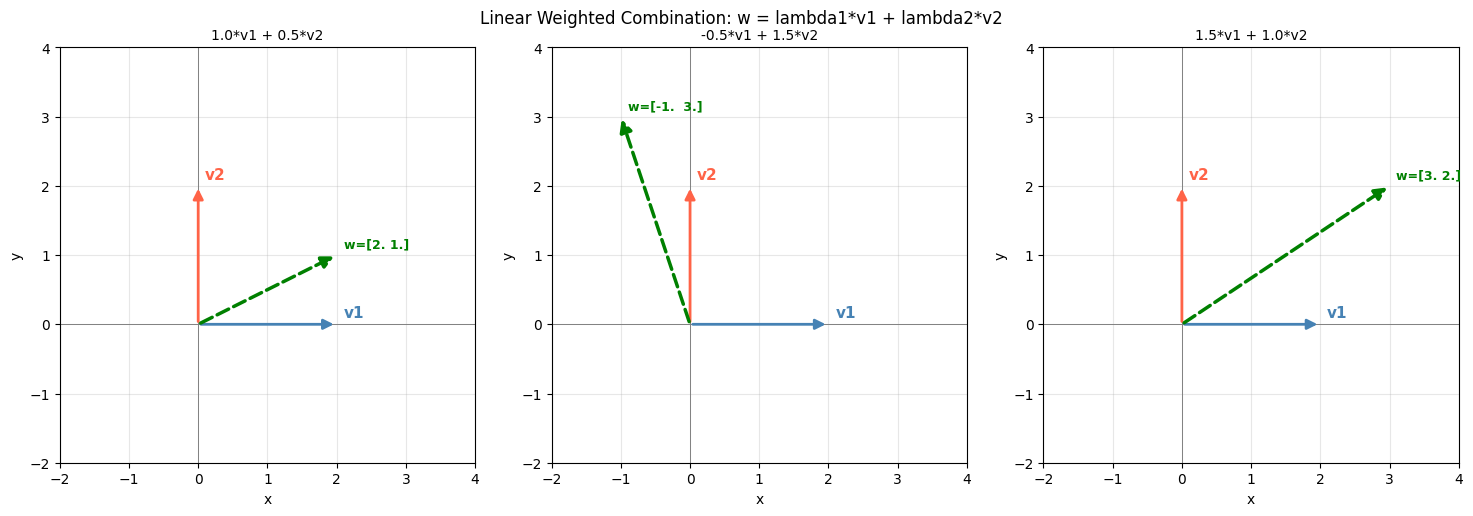

In [20]:
# Visualisasi linear weighted combination di 2D
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

v1_2d = np.array([2, 0])
v2_2d = np.array([0, 2])
origin = np.array([0, 0])

configs = [
    (1.0, 0.5, "1.0*v1 + 0.5*v2"),
    (-0.5, 1.5, "-0.5*v1 + 1.5*v2"),
    (1.5, 1.0, "1.5*v1 + 1.0*v2"),
]

for ax, (l1, l2, title) in zip(axes, configs):
    w_2d = l1*v1_2d + l2*v2_2d

    # Gambar v1
    ax.annotate("", xy=v1_2d, xytext=origin,
                arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2, mutation_scale=15))
    ax.text(v1_2d[0]+0.1, v1_2d[1]+0.1, "v1", color="steelblue", fontsize=11, fontweight="bold")

    # Gambar v2
    ax.annotate("", xy=v2_2d, xytext=origin,
                arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2, mutation_scale=15))
    ax.text(v2_2d[0]+0.1, v2_2d[1]+0.1, "v2", color="tomato", fontsize=11, fontweight="bold")

    # Gambar kombinasi linier
    ax.annotate("", xy=w_2d, xytext=origin,
                arrowprops=dict(arrowstyle="-|>", color="green", lw=2.5, mutation_scale=18,
                                linestyle="dashed"))
    ax.text(w_2d[0]+0.1, w_2d[1]+0.1, f"w={w_2d}", color="green", fontsize=9, fontweight="bold")

    ax.axhline(0, color="gray", lw=0.7)
    ax.axvline(0, color="gray", lw=0.7)
    ax.set_xlim(-2, 4)
    ax.set_ylim(-2, 4)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.suptitle("Linear Weighted Combination: w = lambda1*v1 + lambda2*v2", fontsize=12)
plt.tight_layout()
plt.show()

## 3.3 Linear Independence (Kebebasan Linier)

**Definisi:**

- Sekumpulan vektor bersifat **linearly dependent (bergantung)** jika minimal
  satu vektor dalam himpunan tersebut bisa dinyatakan sebagai linear weighted
  combination dari vektor-vektor lain dalam himpunan yang sama.

- Sekumpulan vektor bersifat **linearly independent (bebas)** jika tidak ada
  vektor dalam himpunan yang bisa dinyatakan sebagai linear weighted combination
  dari vektor lainnya.

### Cara Menentukan Linear Independence

Cara praktis: buat matriks dari vector set, hitung rank matriks tersebut,
lalu bandingkan dengan jumlah kolom (atau baris, yang lebih kecil).

Jika rank = jumlah vektor --> **linearly independent**
Jika rank < jumlah vektor --> **linearly dependent**

(Konsep rank akan dibahas lebih detail di Chapter 6.)

### Fakta Penting: Vektor Nol

Himpunan vektor yang mengandung vektor nol secara otomatis bersifat linearly
dependent, karena vektor nol selalu bisa dinyatakan sebagai kombinasi linier
vektor apapun dengan bobot nol.

In [21]:
# Demonstrasi linear dependence vs independence
print("=== Contoh: Linear Independence vs Dependence ===")
print()

# Set V: independent
V = np.array([[1, 2],
               [3, 7]])  # kolom adalah vektor-vektor
rank_V = np.linalg.matrix_rank(V)
print(f"Set V = [[1,3], [2,7]]")
print(f"  Rank = {rank_V}, Jumlah vektor = {V.shape[1]}")
print(f"  Status: {'INDEPENDENT' if rank_V == V.shape[1] else 'DEPENDENT'}")
print(f"  Alasan: tidak ada skalar lambda sehingga v1 = lambda*v2")
print()

# Set S: dependent
S = np.array([[1, 2],
               [3, 6]])  # kolom kedua = 2x kolom pertama
rank_S = np.linalg.matrix_rank(S)
print(f"Set S = [[1,3], [2,6]]")
print(f"  Rank = {rank_S}, Jumlah vektor = {S.shape[1]}")
print(f"  Status: {'INDEPENDENT' if rank_S == S.shape[1] else 'DEPENDENT'}")
print(f"  Alasan: s2 = 2 * s1  (s2 adalah kelipatan s1)")
print(f"  Verifikasi: s1 = {S[:,0]}, 2*s1 = {2*S[:,0]}, s2 = {S[:,1]}")
print(f"  Identik: {np.allclose(2*S[:,0], S[:,1])}")
print()

# Set T: 4 vektor, dependent
T = np.array([[8, 4, 14, 13],
               [-4, 6, 2, 2],
               [14, 0, 4, 9],
               [6, 3, 7, 8]])
rank_T = np.linalg.matrix_rank(T)
print(f"Set T (4 vektor di R^4):")
print(f"  Rank = {rank_T}, Jumlah vektor = {T.shape[1]}")
print(f"  Status: {'INDEPENDENT' if rank_T == T.shape[1] else 'DEPENDENT'}")
print(f"  Alasan: T[:,0] + T[:,1] + T[:,2] = 2*T[:,3]")
print(f"  Verifikasi: {T[:,0] + T[:,1] + T[:,2]} = 2*{T[:,3]} = {2*T[:,3]}")
print(f"  Benar: {np.allclose(T[:,0]+T[:,1]+T[:,2], 2*T[:,3])}")

=== Contoh: Linear Independence vs Dependence ===

Set V = [[1,3], [2,7]]
  Rank = 2, Jumlah vektor = 2
  Status: INDEPENDENT
  Alasan: tidak ada skalar lambda sehingga v1 = lambda*v2

Set S = [[1,3], [2,6]]
  Rank = 1, Jumlah vektor = 2
  Status: DEPENDENT
  Alasan: s2 = 2 * s1  (s2 adalah kelipatan s1)
  Verifikasi: s1 = [1 3], 2*s1 = [2 6], s2 = [2 6]
  Identik: True

Set T (4 vektor di R^4):
  Rank = 3, Jumlah vektor = 4
  Status: DEPENDENT
  Alasan: T[:,0] + T[:,1] + T[:,2] = 2*T[:,3]
  Verifikasi: [26  4 18 16] = 2*[13  2  9  8] = [26  4 18 16]
  Benar: True


In [22]:
# Cara menentukan independence: menggunakan rank
def check_independence(vectors, names=None):
    M = np.column_stack(vectors)
    rank = np.linalg.matrix_rank(M)
    n_vecs = len(vectors)
    is_independent = (rank == n_vecs)

    if names is None:
        names = [f"v{i+1}" for i in range(n_vecs)]

    print(f"  Matriks dari vector set (shape {M.shape}):")
    print(f"  Rank = {rank} dari {n_vecs} vektor")
    print(f"  Status: {'INDEPENDENT' if is_independent else 'DEPENDENT'}")
    return is_independent

print("=== Pemeriksaan Linear Independence dengan Rank ===")
print()

test_cases = [
    ([np.array([1,0]), np.array([0,1])],   "Basis standar R^2"),
    ([np.array([1,2]), np.array([2,4])],   "Satu vektor = 2x vektor lain"),
    ([np.array([1,0,0]), np.array([0,1,0]), np.array([0,0,1])], "Basis standar R^3"),
    ([np.array([1,2,3]), np.array([4,5,6]), np.array([7,8,9])], "3 vektor R^3 (bergantung)"),
]

for vecs, desc in test_cases:
    print(f"Kasus: {desc}")
    check_independence(vecs)
    print()

=== Pemeriksaan Linear Independence dengan Rank ===

Kasus: Basis standar R^2
  Matriks dari vector set (shape (2, 2)):
  Rank = 2 dari 2 vektor
  Status: INDEPENDENT

Kasus: Satu vektor = 2x vektor lain
  Matriks dari vector set (shape (2, 2)):
  Rank = 1 dari 2 vektor
  Status: DEPENDENT

Kasus: Basis standar R^3
  Matriks dari vector set (shape (3, 3)):
  Rank = 3 dari 3 vektor
  Status: INDEPENDENT

Kasus: 3 vektor R^3 (bergantung)
  Matriks dari vector set (shape (3, 3)):
  Rank = 2 dari 3 vektor
  Status: DEPENDENT



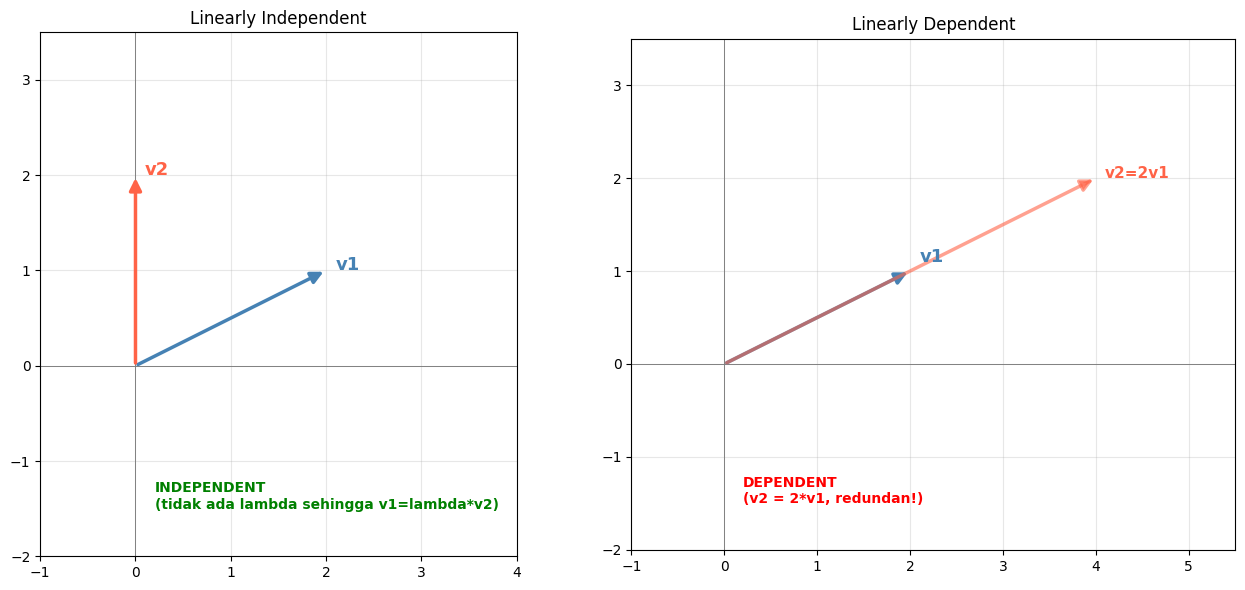

In [23]:
# Visualisasi: independent vs dependent vectors di 2D
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Kiri: independent (bentuk "V")
ax = axes[0]
v1_ind = np.array([2, 1])
v2_ind = np.array([0, 2])
ax.annotate("", xy=v1_ind, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax.annotate("", xy=v2_ind, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18))
ax.text(v1_ind[0]+0.1, v1_ind[1], "v1", color="steelblue", fontsize=13, fontweight="bold")
ax.text(v2_ind[0]+0.1, v2_ind[1], "v2", color="tomato", fontsize=13, fontweight="bold")
ax.text(0.2, -1.5, "INDEPENDENT\n(tidak ada lambda sehingga v1=lambda*v2)",
        fontsize=10, color="green", fontweight="bold")
ax.axhline(0, color="gray", lw=0.7)
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlim(-1, 4)
ax.set_ylim(-2, 3.5)
ax.grid(True, alpha=0.3)
ax.set_title("Linearly Independent", fontsize=12)
ax.set_aspect("equal")

# Kanan: dependent (searah)
ax = axes[1]
v1_dep = np.array([2, 1])
v2_dep = np.array([4, 2])  # = 2 * v1_dep
ax.annotate("", xy=v1_dep, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax.annotate("", xy=v2_dep, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18,
                            alpha=0.6))
ax.text(v1_dep[0]+0.1, v1_dep[1]+0.1, "v1", color="steelblue", fontsize=13, fontweight="bold")
ax.text(v2_dep[0]+0.1, v2_dep[1], "v2=2v1", color="tomato", fontsize=11, fontweight="bold")
ax.text(0.2, -1.5, "DEPENDENT\n(v2 = 2*v1, redundan!)",
        fontsize=10, color="red", fontweight="bold")
ax.axhline(0, color="gray", lw=0.7)
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlim(-1, 5.5)
ax.set_ylim(-2, 3.5)
ax.grid(True, alpha=0.3)
ax.set_title("Linearly Dependent", fontsize=12)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 3.4 Subspace dan Span

### Span

**Span** adalah mekanisme: himpunan dari semua kemungkinan linear weighted
combination menggunakan vektor-vektor dalam suatu set (dengan bobot lambda
yang bisa berupa semua bilangan real).

Bayangkan memutar "kenop" lambda dari -inf ke +inf untuk setiap vektor dalam
set -- semua vektor yang bisa dihasilkan membentuk span dari set tersebut.

### Subspace

**Subspace** adalah hasil dari spanning: himpunan vektor tak terbatas yang
terbentuk dari semua linear weighted combination.

Definisi formal: subset yang:
1. Tertutup terhadap penjumlahan dan perkalian skalar
2. Mengandung titik asal (vektor nol)

### Hubungan Dimensi Subspace dan Jumlah Vektor

- 1 vektor independent --> span 1D (garis)
- 2 vektor independent di R^3 --> span 2D (bidang)
- 2 vektor dependent --> span 1D (meskipun ada 2 vektor)

**Kunci:** dimensi subspace = jumlah vektor yang linearly independent dalam set.

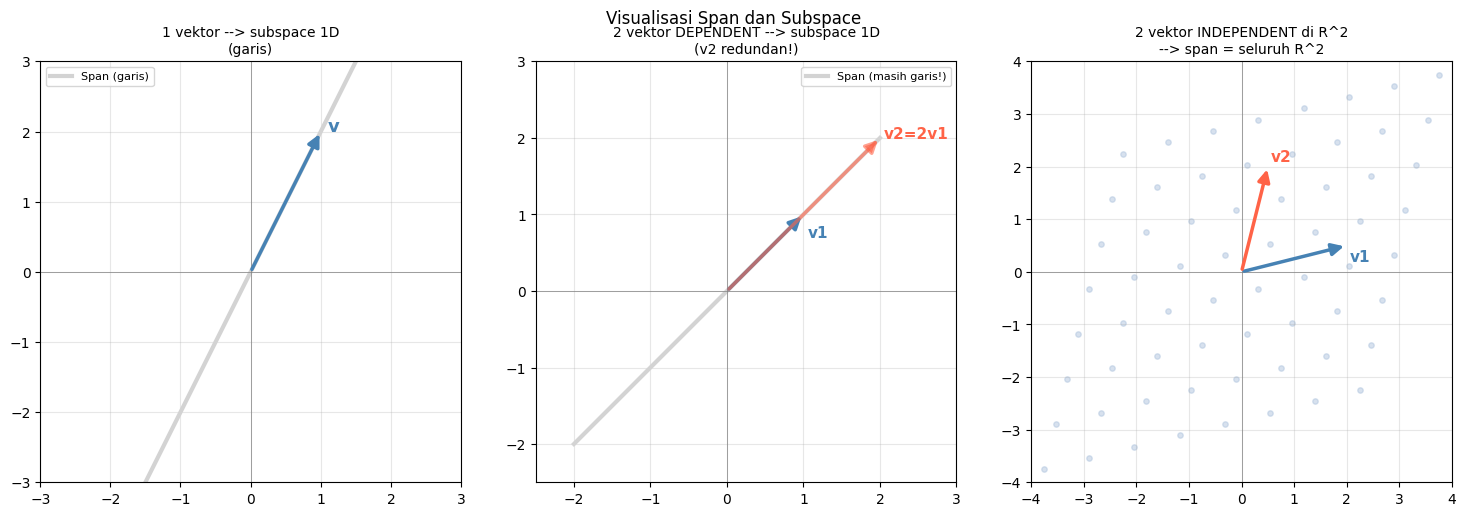

In [24]:
# Visualisasi subspace di 2D dan 3D

fig = plt.figure(figsize=(15, 5))

# Kiri: 1 vektor, span = garis (1D subspace)
ax1 = fig.add_subplot(131)
v_1d = np.array([1, 2])
t_vals = np.linspace(-2.5, 2.5, 100)
span_x = t_vals * v_1d[0]
span_y = t_vals * v_1d[1]
ax1.plot(span_x, span_y, color="lightgray", lw=3, label="Span (garis)")
ax1.annotate("", xy=v_1d, xytext=(0,0),
             arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax1.text(v_1d[0]+0.1, v_1d[1], "v", color="steelblue", fontsize=13, fontweight="bold")
ax1.axhline(0, color="gray", lw=0.5)
ax1.axvline(0, color="gray", lw=0.5)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.set_aspect("equal")
ax1.grid(True, alpha=0.3)
ax1.set_title("1 vektor --> subspace 1D\n(garis)", fontsize=10)
ax1.legend(fontsize=8)

# Tengah: 2 vektor dependent, span = garis (1D)
ax2 = fig.add_subplot(132)
v1 = np.array([1, 1])
v2 = np.array([2, 2])  # v2 = 2*v1, dependent
t_vals2 = np.linspace(-2, 2, 100)
ax2.plot(t_vals2 * v1[0], t_vals2 * v1[1], color="lightgray", lw=3, label="Span (masih garis!)")
ax2.annotate("", xy=v1, xytext=(0,0),
             arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax2.annotate("", xy=v2, xytext=(0,0),
             arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18, alpha=0.6))
ax2.text(v1[0]+0.05, v1[1]-0.3, "v1", color="steelblue", fontsize=11, fontweight="bold")
ax2.text(v2[0]+0.05, v2[1], "v2=2v1", color="tomato", fontsize=11, fontweight="bold")
ax2.axhline(0, color="gray", lw=0.5)
ax2.axvline(0, color="gray", lw=0.5)
ax2.set_xlim(-2.5, 3)
ax2.set_ylim(-2.5, 3)
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)
ax2.set_title("2 vektor DEPENDENT --> subspace 1D\n(v2 redundan!)", fontsize=10)
ax2.legend(fontsize=8)

# Kanan: 2 vektor independent di R^2, span = R^2
ax3 = fig.add_subplot(133)
v1_ind = np.array([2, 0.5])
v2_ind = np.array([0.5, 2])
# Visualisasi beberapa titik dari span
lambdas = np.linspace(-1.5, 1.5, 8)
for l1 in lambdas:
    for l2 in lambdas:
        pt = l1*v1_ind + l2*v2_ind
        ax3.scatter(pt[0], pt[1], color="lightsteelblue", s=15, alpha=0.5, zorder=1)

ax3.annotate("", xy=v1_ind, xytext=(0,0),
             arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax3.annotate("", xy=v2_ind, xytext=(0,0),
             arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18))
ax3.text(v1_ind[0]+0.05, v1_ind[1]-0.3, "v1", color="steelblue", fontsize=11, fontweight="bold")
ax3.text(v2_ind[0]+0.05, v2_ind[1]+0.1, "v2", color="tomato", fontsize=11, fontweight="bold")
ax3.axhline(0, color="gray", lw=0.5)
ax3.axvline(0, color="gray", lw=0.5)
ax3.set_xlim(-4, 4)
ax3.set_ylim(-4, 4)
ax3.set_aspect("equal")
ax3.grid(True, alpha=0.3)
ax3.set_title("2 vektor INDEPENDENT di R^2\n--> span = seluruh R^2", fontsize=10)

plt.suptitle("Visualisasi Span dan Subspace", fontsize=12)
plt.tight_layout()
plt.show()

## 3.5 Basis (Dasar Ruang Vektor)

### Analogi

Bayangkan jarak antara Jakarta dan Bali kira-kira 1.200. Angka "1.200" hanya
bermakna jika kita mengetahui satuan ukurannya. Satuan tersebut adalah **basis**.

Kita bisa menggunakan meter, kilometer, atau mil sebagai basis -- hasilnya berbeda
tapi keduanya mendeskripsikan jarak yang sama. Beberapa basis lebih nyaman
untuk masalah tertentu.

### Definisi Formal Basis

Sebuah himpunan vektor bisa menjadi **basis** untuk suatu subspace jika:
1. **Span**: himpunan tersebut mencakup (span) seluruh subspace tersebut
2. **Independent**: himpunan tersebut adalah linearly independent

Basis memberikan representasi **unik** untuk setiap titik dalam subspace.

### Basis Standar (Standard Basis)

Basis paling umum adalah sumbu Kartesius:

    S2 = {[1,0], [0,1]}     (untuk R^2)
    S3 = {[1,0,0], [0,1,0], [0,0,1]}  (untuk R^3)

Basis standar terdiri dari vektor yang:
- Saling ortogonal (tegak lurus)
- Berukuran unit (panjang = 1)

### Basis Berbeda untuk Subspace yang Sama

Bisa ada banyak basis berbeda untuk subspace yang sama. Dalam data science:
PCA, ICA, dan SVD pada dasarnya mencari basis optimal untuk mendeskripsikan data.

In [25]:
# Basis standar dan basis alternatif
print("=== Basis Standar R^2 ===")
S2 = np.array([[1, 0],
                [0, 1]])
print(f"e1 = {S2[:,0]}  (vektor basis ke-1)")
print(f"e2 = {S2[:,1]}  (vektor basis ke-2)")
print()

print("=== Basis Alternatif T untuk R^2 ===")
T = np.array([[3, -3],
               [1,  1]])
print(f"t1 = {T[:,0]}")
print(f"t2 = {T[:,1]}")
print()

# Periksa apakah T adalah basis yang valid
rank_T = np.linalg.matrix_rank(T)
print(f"Rank T = {rank_T} dari {T.shape[1]} vektor")
print(f"T adalah basis valid: {rank_T == T.shape[1]}")
print()

# Ekspresikan titik data dalam basis S vs T
# Titik p = [3,1] dan q = [-6,2]
p = np.array([3, 1])
q = np.array([-6, 2])

print("=== Titik p dan q dalam Basis S (standar) ===")
print(f"p = {p[0]}*e1 + {p[1]}*e2  -->  koordinat ({p[0]}, {p[1]})")
print(f"q = {q[0]}*e1 + {q[1]}*e2  -->  koordinat ({q[0]}, {q[1]})")
print()

# Hitung koordinat dalam basis T menggunakan inverse
T_inv = np.linalg.inv(T)
p_in_T = T_inv @ p
q_in_T = T_inv @ q
print("=== Titik p dan q dalam Basis T ===")
print(f"p = {p_in_T[0]:.4f}*t1 + {p_in_T[1]:.4f}*t2  -->  koordinat ({p_in_T[0]:.4f}, {p_in_T[1]:.4f})")
print(f"q = {q_in_T[0]:.4f}*t1 + {q_in_T[1]:.4f}*t2  -->  koordinat ({q_in_T[0]:.4f}, {q_in_T[1]:.4f})")
print()
print("Titik yang sama, representasi berbeda tergantung basis!")

=== Basis Standar R^2 ===
e1 = [1 0]  (vektor basis ke-1)
e2 = [0 1]  (vektor basis ke-2)

=== Basis Alternatif T untuk R^2 ===
t1 = [3 1]
t2 = [-3  1]

Rank T = 2 dari 2 vektor
T adalah basis valid: True

=== Titik p dan q dalam Basis S (standar) ===
p = 3*e1 + 1*e2  -->  koordinat (3, 1)
q = -6*e1 + 2*e2  -->  koordinat (-6, 2)

=== Titik p dan q dalam Basis T ===
p = 1.0000*t1 + 0.0000*t2  -->  koordinat (1.0000, 0.0000)
q = 0.0000*t1 + 2.0000*t2  -->  koordinat (0.0000, 2.0000)

Titik yang sama, representasi berbeda tergantung basis!


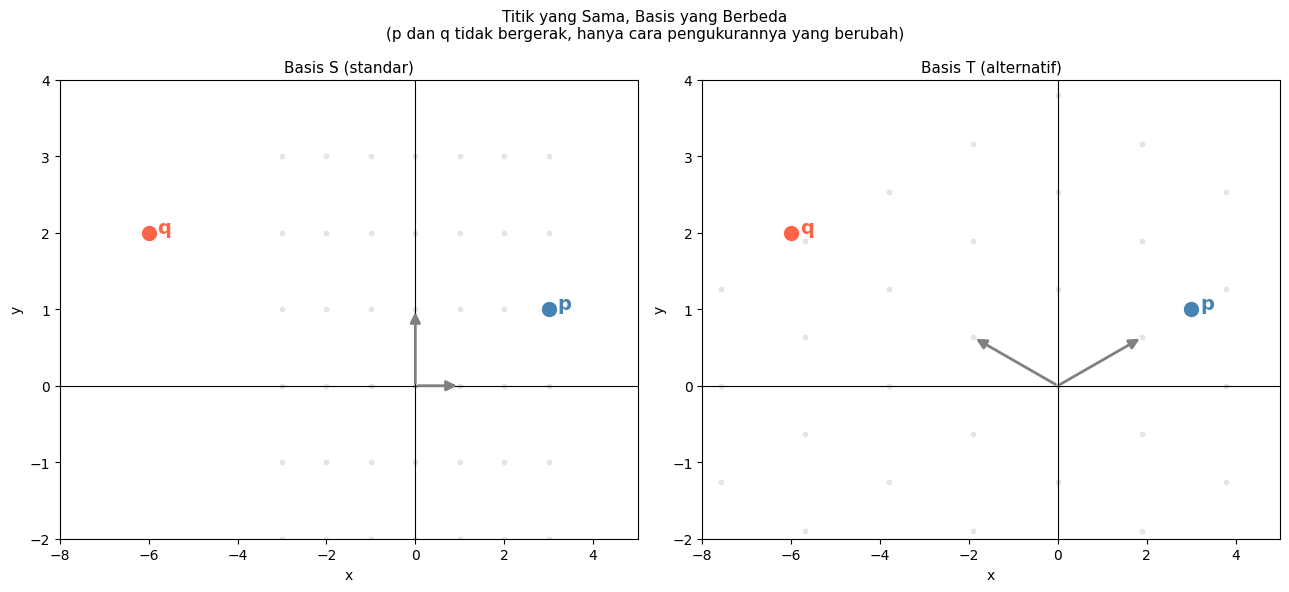

In [26]:
# Visualisasi: titik yang sama dalam basis berbeda
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

p_data = np.array([3.0, 1.0])
q_data = np.array([-6.0, 2.0])

# Basis S (standar)
e1 = np.array([1, 0])
e2 = np.array([0, 1])

# Basis T
t1 = np.array([3, 1])
t2 = np.array([-3, 1])

for ax_idx, (ax, basis_vecs, title) in enumerate(zip(
    axes,
    [(e1, e2), (t1/np.linalg.norm(t1)*2, t2/np.linalg.norm(t2)*2)],
    ["Basis S (standar)", "Basis T (alternatif)"]
)):
    bv1, bv2 = basis_vecs

    # Grid dari basis
    for scale in np.arange(-3, 4, 1):
        for sc2 in np.arange(-3, 4, 1):
            pt = scale * bv1 + sc2 * bv2
            ax.scatter(pt[0], pt[1], color="lightgray", s=10, alpha=0.5)

    # Gambar vektor basis
    ax.annotate("", xy=bv1, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color="gray", lw=2, mutation_scale=15))
    ax.annotate("", xy=bv2, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color="gray", lw=2, mutation_scale=15))

    # Plot titik data
    ax.scatter(p_data[0], p_data[1], color="steelblue", s=100, zorder=5)
    ax.text(p_data[0]+0.2, p_data[1], "p", color="steelblue", fontsize=14, fontweight="bold")

    ax.scatter(q_data[0], q_data[1], color="tomato", s=100, zorder=5)
    ax.text(q_data[0]+0.2, q_data[1], "q", color="tomato", fontsize=14, fontweight="bold")

    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlim(-8, 5)
    ax.set_ylim(-2, 4)
    ax.grid(False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Titik yang Sama, Basis yang Berbeda\n(p dan q tidak bergerak, hanya cara pengukurannya yang berubah)",
             fontsize=11)
plt.tight_layout()
plt.show()

In [27]:
# Soft proof: properti basis
print("=== Properti Basis ===")
print()

# Uji: apakah setiap vektor di R^2 bisa dinyatakan UNIK dalam basis T?
T_mat = np.array([[3.0, -3.0],
                   [1.0,  1.0]])

test_points = [
    np.array([3, 1]),
    np.array([-6, 2]),
    np.array([0, 0]),
    np.array([5, -2]),
]

print(f"{'Titik':<15} {'Koordinat dalam T':<25} {'Rekonstruksi':<20} {'Cocok?'}")
print("-" * 75)
T_inv = np.linalg.inv(T_mat)
for pt in test_points:
    coords = T_inv @ pt
    recon  = T_mat @ coords
    ok     = np.allclose(pt, recon)
    print(f"{str(pt):<15} {str(np.round(coords,4)):<25} {str(np.round(recon,4)):<20} {ok}")

print()
print("Setiap titik punya representasi UNIK dalam basis T.")
print("Inilah mengapa linear independence diperlukan dalam definisi basis!")

=== Properti Basis ===

Titik           Koordinat dalam T         Rekonstruksi         Cocok?
---------------------------------------------------------------------------
[3 1]           [1. 0.]                   [3. 1.]              True
[-6  2]         [0. 2.]                   [-6.  2.]            True
[0 0]           [0. 0.]                   [0. 0.]              True
[ 5 -2]         [-0.1667 -1.8333]         [ 5. -2.]            True

Setiap titik punya representasi UNIK dalam basis T.
Inilah mengapa linear independence diperlukan dalam definisi basis!


## 3.6 Latihan Kode

Latihan-latihan ini dirancang untuk memperkuat pemahaman konsep chapter ini.

In [28]:
# Latihan 1: Soft proof -- linear weighted combination
# Verifikasi bahwa kombinasi linear dari vektor-vektor yang span R^2
# bisa menghasilkan vektor apapun di R^2

print("=== Latihan 1: LWC Bisa Menghasilkan Vektor Apapun di Span-nya ===")

v1 = np.array([1.0, 0.0])  # basis standar e1
v2 = np.array([0.0, 1.0])  # basis standar e2

targets = [np.array([3.0, 5.0]), np.array([-2.0, 4.0]), np.array([0.7, -1.3])]

for target in targets:
    # Untuk basis standar, koordinat = elemen vektor itu sendiri
    l1, l2 = target[0], target[1]
    result = l1*v1 + l2*v2
    print(f"  Target={target}: {l1:.1f}*e1 + {l2:.1f}*e2 = {result} | Cocok: {np.allclose(result, target)}")

=== Latihan 1: LWC Bisa Menghasilkan Vektor Apapun di Span-nya ===
  Target=[3. 5.]: 3.0*e1 + 5.0*e2 = [3. 5.] | Cocok: True
  Target=[-2.  4.]: -2.0*e1 + 4.0*e2 = [-2.  4.] | Cocok: True
  Target=[ 0.7 -1.3]: 0.7*e1 + -1.3*e2 = [ 0.7 -1.3] | Cocok: True


In [29]:
# Latihan 2: Tentukan independence untuk berbagai set vektor
print("=== Latihan 2: Uji Linear Independence ===")
print()

test_sets = [
    ([np.array([1,0,0]), np.array([0,1,0]), np.array([0,0,1])], "Basis standar R^3"),
    ([np.array([1,2,3]), np.array([2,4,6])],                      "2 vektor R^3 (satu kelipatan)"),
    ([np.array([1,0]), np.array([0,1]), np.array([1,1])],          "3 vektor di R^2 (overdetermined)"),
    ([np.array([1,2,3,4]), np.array([5,6,7,8]), np.array([9,10,11,12])], "3 vektor R^4"),
]

for vecs, desc in test_sets:
    M = np.column_stack(vecs)
    rank = np.linalg.matrix_rank(M)
    n = len(vecs)
    status = "INDEPENDENT" if rank == n else f"DEPENDENT (rank={rank} < n={n})"
    print(f"Set: {desc}")
    print(f"  Jumlah vektor: {n}, Rank: {rank} --> {status}")
    print()

=== Latihan 2: Uji Linear Independence ===

Set: Basis standar R^3
  Jumlah vektor: 3, Rank: 3 --> INDEPENDENT

Set: 2 vektor R^3 (satu kelipatan)
  Jumlah vektor: 2, Rank: 1 --> DEPENDENT (rank=1 < n=2)

Set: 3 vektor di R^2 (overdetermined)
  Jumlah vektor: 3, Rank: 2 --> DEPENDENT (rank=2 < n=3)

Set: 3 vektor R^4
  Jumlah vektor: 3, Rank: 2 --> DEPENDENT (rank=2 < n=3)



In [30]:
# Latihan 3: Verifikasi sifat subspace
# Subspace harus tertutup: kombinasi dari vektor-vektor di dalamnya harus tetap di subspace

print("=== Latihan 3: Closure Property Subspace ===")
print()

# Subspace: span dari v = [1,2] (garis di R^2)
v_span = np.array([1.0, 2.0])

# Ambil dua vektor sembarang dari span ini
w1 = 3.0 * v_span   # [3, 6]
w2 = -1.5 * v_span  # [-1.5, -3]

# Kombinasi linear dari w1 dan w2 harus masih di span
l1, l2 = 2.0, 1.5
combo = l1*w1 + l2*w2

# Cek apakah combo masih di span: combo = k * v_span untuk suatu k
k = combo[0] / v_span[0]
is_in_span = np.isclose(combo, k * v_span)

print(f"Vektor basis span: v = {v_span}")
print(f"w1 = 3*v = {w1}")
print(f"w2 = -1.5*v = {w2}")
print(f"{l1}*w1 + {l2}*w2 = {combo}")
print(f"Apakah combo = {k:.2f}*v? {is_in_span} --> combo tetap di span!")
print()
print("Kesimpulan: subspace tertutup terhadap linear weighted combination.")

=== Latihan 3: Closure Property Subspace ===

Vektor basis span: v = [1. 2.]
w1 = 3*v = [3. 6.]
w2 = -1.5*v = [-1.5 -3. ]
2.0*w1 + 1.5*w2 = [3.75 7.5 ]
Apakah combo = 3.75*v? [ True  True] --> combo tetap di span!

Kesimpulan: subspace tertutup terhadap linear weighted combination.


## 3.7 Ringkasan Chapter 3

### Konsep Kunci

| Konsep | Definisi | Kepentingan |
|--------|----------|-------------|
| Vector Set | Kumpulan vektor | Container untuk operasi bersama |
| LWC | Skalar kali vektor, lalu jumlahkan | Blok pembangun aljabar linear |
| Linear Independence | Tidak ada vektor yang bisa dinyatakan sbg LWC vektor lain | Syarat untuk basis |
| Span | Semua LWC dari suatu set | Mekanisme membentuk subspace |
| Subspace | Hasil dari spanning, tertutup terhadap LWC | Ruang yang bisa "diukur" basis |
| Basis | Set yang span subspace dan independent | Sistem koordinat untuk subspace |

### Aturan Praktis

- Untuk menentukan independence: hitung rank matriks yang dibentuk dari vektor-vektor tersebut
- Rank = jumlah vektor --> independent
- Rank < jumlah vektor --> dependent (ada vektor yang redundan)
- Himpunan dengan vektor nol selalu dependent
- Basis harus memenuhi DUA syarat: span DAN independent

### Koneksi ke Aplikasi Data Science

- **PCA**: mencari basis optimal yang memaksimalkan variansi data
- **SVD**: dekomposisi berbasis basis ortogonal
- **Regresi linear**: kolom-kolom matriks desain harus independent (tidak ada multikolinearitas)
- **Neural Network**: setiap layer = linear weighted combination + aktivasi non-linear